# 从零训练 HSTU-inspired 微型推荐器

全部实验在 CPU 上运行，无模型下载。使用合成数据、单头、简化相对位置偏置；不是官方 HSTU 复现，不含工业特征、Stochastic Length 或 M-FALCON。数据与模型在下方完整定义。图中的 loss 和 top-k 来自本次真实训练。

执行状态：编写时已在 CPU 上运行，下方为真实输出；CUDA/TPU 路径未经测试。请重新运行以获取你的环境结果。

In [1]:
import sys, subprocess, importlib.util
needed = [p for p in ['torch','transformers','numpy','matplotlib','PIL'] if importlib.util.find_spec(p) is None]
if needed:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torch>=2.6,<3', 'transformers==4.57.1', 'numpy', 'matplotlib', 'pillow'])
import torch, numpy as np, matplotlib.pyplot as plt, transformers
print({'python':sys.version.split()[0], 'torch':torch.__version__, 'transformers':transformers.__version__, 'cuda':torch.cuda.is_available()})
torch.manual_seed(7); np.random.seed(7)
torch.set_num_threads(min(4, torch.get_num_threads()))


{'python': '3.12.14', 'torch': '2.14.0+cpu', 'transformers': '4.57.1', 'cuda': False}


## 1 · 可控序列数据
两组商品循环，0 保留给 padding。保留不同起点作简单测试；这不是现实分布的泛化证明。

In [2]:
import torch.nn as nn
import torch.nn.functional as F
cycles=[[1,2,3,4],[5,6,7,8]]
def sequence(cycle,start,length=9):return [cycle[(start+j)%len(cycle)] for j in range(length)]
train=torch.tensor([sequence(c,start) for c in cycles for start in [0,1]])
valid=torch.tensor([sequence(c,start) for c in cycles for start in [2,3]])
inputs,targets=train[:,:-1],train[:,1:]
print('train:',train.tolist(),'held-out:',valid.tolist())


train: [[1, 2, 3, 4, 1, 2, 3, 4, 1], [2, 3, 4, 1, 2, 3, 4, 1, 2], [5, 6, 7, 8, 5, 6, 7, 8, 5], [6, 7, 8, 5, 6, 7, 8, 5, 6]] held-out: [[3, 4, 1, 2, 3, 4, 1, 2, 3], [4, 1, 2, 3, 4, 1, 2, 3, 4], [7, 8, 5, 6, 7, 8, 5, 6, 7], [8, 5, 6, 7, 8, 5, 6, 7, 8]]


## 2 · 定义完整教学模型
先 norm，再融合投影为 U/V/Q/K；用 causal 与有效 key mask，归一化聚合后由 U 门控。

In [3]:
class TinyHSTU(nn.Module):
    def __init__(self,vocab=9,dim=24):
        super().__init__()
        self.embedding=nn.Embedding(vocab,dim,padding_idx=0)
        self.norm=nn.LayerNorm(dim)
        self.uvqk=nn.Linear(dim,4*dim)
        self.aggregate_norm=nn.LayerNorm(dim)
        self.output=nn.Linear(dim,dim)
        self.head=nn.Linear(dim,vocab)
        self.time_strength=nn.Parameter(torch.tensor(.1))
    def forward(self,ids):
        x=self.embedding(ids);b,t,d=x.shape
        u,v,q,k=F.silu(self.uvqk(self.norm(x))).chunk(4,-1)
        positions=torch.arange(t,device=ids.device)
        age=(positions[:,None]-positions[None,:]).clamp_min(0).float()
        score=q@k.transpose(-2,-1)-self.time_strength.abs()*age
        allowed=(positions[None,:]<=positions[:,None])[None]&ids.ne(0)[:,None,:]
        a=(F.silu(score)/t).masked_fill(~allowed,0)
        h=x+self.output(u*self.aggregate_norm(a@v))
        return self.head(h)
model=TinyHSTU()
print(model)
print('parameters:',sum(p.numel() for p in model.parameters()))
print('logits:',model(inputs).shape)


TinyHSTU(
  (embedding): Embedding(9, 24, padding_idx=0)
  (norm): LayerNorm((24,), eps=1e-05, elementwise_affine=True, bias=True)
  (uvqk): Linear(in_features=24, out_features=96, bias=True)
  (aggregate_norm): LayerNorm((24,), eps=1e-05, elementwise_affine=True, bias=True)
  (output): Linear(in_features=24, out_features=24, bias=True)
  (head): Linear(in_features=24, out_features=9, bias=True)
)
parameters: 3538
logits: torch.Size([4, 8, 9])


## 3 · 真正训练并画 loss
修改学习率或步数，观察是否收敛。grad_norm 只是诊断，不是质量指标。

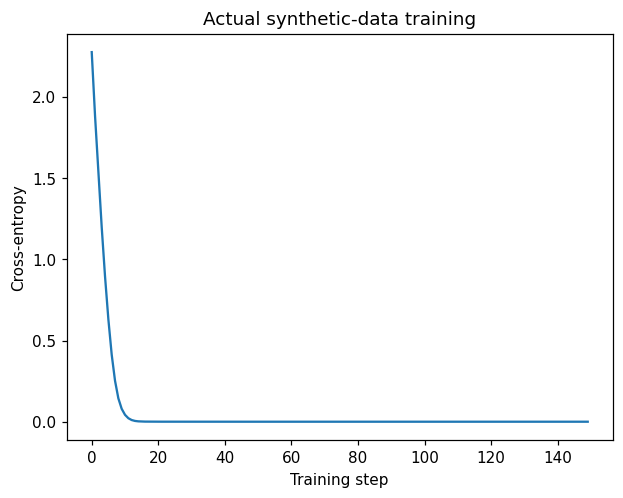

initial / final loss: 2.2755558490753174 2.011644710364635e-06 last grad norm: 4.408008317113854e-05


In [4]:
optimizer=torch.optim.AdamW(model.parameters(),lr=.01)
losses=[]
for step in range(150):
    model.train()
    logits=model(inputs)
    loss=F.cross_entropy(logits.reshape(-1,9),targets.reshape(-1),ignore_index=0)
    optimizer.zero_grad(set_to_none=True);loss.backward()
    grad_norm=nn.utils.clip_grad_norm_(model.parameters(),1.0)
    optimizer.step();losses.append(loss.item())
print('initial / final loss:',losses[0],losses[-1],'last grad norm:',float(grad_norm))
assert np.isfinite(losses).all() and losses[-1]<losses[0]
plt.plot(losses);plt.xlabel('Training step');plt.ylabel('Cross-entropy');plt.title('Actual synthetic-data training');plt.show()


## 4 · 因果与 padding 测试
改变未来 token；再改变 padding embedding。合法的较早输出不能变化。

In [5]:
model.eval()
with torch.no_grad():
    base=model(inputs)
    changed=inputs.clone();changed[:,-1]=8
    future_changed=model(changed)
    assert torch.allclose(base[:,:-1],future_changed[:,:-1],atol=1e-6)
    padded=torch.tensor([[1,2,0,0]])
    original=model(padded)[:,:2]
    old=model.embedding.weight[0].clone()
    model.embedding.weight[0].fill_(100.)
    modified=model(padded)[:,:2]
    model.embedding.weight[0].copy_(old)
    assert torch.allclose(original,modified,atol=1e-6)
print('Causality and padding checks passed.')


Causality and padding checks passed.


## 5 · 推荐输出与 holdout 指标
屏蔽 ID 0。保持重复消费候选，因为此任务本身是循环行为。

In [6]:
with torch.no_grad():
    scores=model(valid[:,:-1])[:,-1].clone();scores[:,0]=-torch.inf
    top=scores.topk(3,-1).indices
    truth=valid[:,-1]
    hit=(top==truth[:,None])
    hr3=hit.any(-1).float().mean().item()
    discounts=1/torch.log2(torch.arange(2,5).float())
    ndcg3=(hit.float()*discounts).sum(-1).mean().item()
print('HR@3:',hr3,'NDCG@3:',ndcg3)
for seq,pred,target in zip(valid[:,:-1].tolist(),top.tolist(),truth.tolist()):
    print('history:',seq,'top3:',pred,'target:',target)
assert not (top==0).any()


HR@3: 1.0 NDCG@3: 1.0
history: [3, 4, 1, 2, 3, 4, 1, 2] top3: [3, 1, 8] target: 3
history: [4, 1, 2, 3, 4, 1, 2, 3] top3: [4, 6, 8] target: 4
history: [7, 8, 5, 6, 7, 8, 5, 6] top3: [7, 2, 6] target: 7
history: [8, 5, 6, 7, 8, 5, 6, 7] top3: [8, 3, 1] target: 8


## 下一步
改变一个参数，先预测结果，再重跑。记录环境、seed、输入与失败情况；不要把教学实验外推成生产结论。